In [0]:
# Databricks Notebook: Python, Pandas & NumPy Basics for Data Analysis (2 Hours)
# Data source: workspace.trabajoenclase.superstore

# =====================================================
# 1. Introduction & Setup
# =====================================================
# Goals of this notebook:
# - Learn Databricks basics
# - Load Databricks table using Pandas
# - Understand Pandas & NumPy fundamentals
# - Perform basic data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# 2. Load Data using Pandas (from Spark Table)
# =====================================================
# Databricks tables are Spark tables, so we:
# 1. Read with Spark
# 2. Convert to Pandas for analysis

spark_df = spark.table("workspace.diagnosticopredictibilidad.superstore")

# Convert to Pandas DataFrame
pdf = spark_df.toPandas()

pdf.head()


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Delivery Days,order year,order month
0,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,Oklahoma City,Oklahoma,United States,Central US,USCA,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221,2,0.0,62,40,High,2,2014,11
1,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,Oceania,Asia Pacific,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709,9,0.1,-288,923,Critical,2,2014,2
2,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,Brisbane,Queensland,Australia,Oceania,Asia Pacific,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175,9,0.1,919,915,Medium,1,2014,10
3,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,Berlin,Berlin,Germany,Western Europe,Europe,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892,5,0.1,-96,910,Medium,2,2014,1
4,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Western Africa,Africa,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832,8,0.0,311,903,Critical,1,2014,11


In [0]:

# =====================================================
# 3. Pandas Basics
# =====================================================
# =====================================================================
# DIAGNÓSTICO INICIAL DEL DATASET
# =====================================================================

# 1. pdf.shape: Devuelve una tupla (filas, columnas).
# Sirve para saber el tamaño exacto de la tabla (cantidad de registros y variables).
pdf.shape

# 2. pdf.columns: Devuelve el listado de nombres de las variables.
# Sirve para conocer y copiar exactamente los nombres de las columnas para usos futuros.
pdf.columns

# 3. pdf.dtypes: Muestra el tipo de dato (ej. 'int64' enteros, 'float64' decimales, 'object' texto).
# Sirve para verificar si los datos cargaron en el formato correcto para hacer cálculos o predicciones.
pdf.dtypes

# 4. pdf.describe(): Genera resumen estadístico (conteo, media, std, min, max, cuartiles) de las columnas numéricas.
# Sirve para entender la distribución, los promedios y detectar si existen valores atípicos (outliers).
pdf.describe()

# 5. pdf.info(): Muestra un resumen general de la estructura, uso de memoria y conteo de valores no nulos.
# Sirve para revisar rápidamente la calidad del dataset y detectar si hay columnas con datos faltantes o vacíos.
pdf.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        51290 non-null  object 
 1   Order Date      51290 non-null  object 
 2   Ship Date       51290 non-null  object 
 3   Ship Mode       51290 non-null  object 
 4   Customer ID     51290 non-null  object 
 5   Customer Name   51290 non-null  object 
 6   Segment         51290 non-null  object 
 7   City            51290 non-null  object 
 8   State           51290 non-null  object 
 9   Country         51290 non-null  object 
 10  Region          51290 non-null  object 
 11  Market          51290 non-null  object 
 12  Product ID      51290 non-null  object 
 13  Category        51290 non-null  object 
 14  Sub-Category    51290 non-null  object 
 15  Product Name    51290 non-null  object 
 16  Sales           51290 non-null  int64  
 17  Quantity        51290 non-null 

In [0]:
# =====================================================
# 4. Basic Data Selection
# =====================================================

# Select one column
pdf["Sales"].head()


0     221
1    3709
2    5175
3    2892
4    2832
Name: Sales, dtype: int64

In [0]:

# Select multiple columns
pdf[["Category", "Sales", "Profit"]].head()



,Category,Sales,Profit
0,Technology,221,62
1,Furniture,3709,-288
2,Technology,5175,919
3,Technology,2892,-96
4,Technology,2832,311


In [0]:

# Filter rows
pdf[pdf["Sales"] > 500].head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Delivery Days,order year,order month
1,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,Oceania,Asia Pacific,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709,9,0.1,-288,923,Critical,2,2014,2
2,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,Brisbane,Queensland,Australia,Oceania,Asia Pacific,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175,9,0.1,919,915,Medium,1,2014,10
3,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,Berlin,Berlin,Germany,Western Europe,Europe,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892,5,0.1,-96,910,Medium,2,2014,1
4,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Western Africa,Africa,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832,8,0.0,311,903,Critical,1,2014,11
5,IN-2014-JM156557-41818,2014-06-28,2014-07-01,Second Class,JM-156557,Jim Mitchum,Corporate,Sydney,New South Wales,Australia,Oceania,Asia Pacific,TEC-PH-5842,Technology,Phones,"Samsung Smart Phone, with Caller ID",2862,5,0.1,763,897,Critical,3,2014,6


In [0]:

# =====================================================
# 5. Data Cleaning with Pandas
# =====================================================
# CONTEO EXACTO DE VALORES NULOS O FALTANTES
# =====================================================================

# pdf.isna().sum():
# .isna() detecta los valores nulos (convirtiéndolos en 1) y .sum() los suma por columna.
# Sirve para identificar la cantidad exacta de datos faltantes en cada variable.
# Esto es crítico para decidir la estrategia de limpieza: imputar (rellenar) los datos o eliminar la variable.
pdf.isna().sum()

Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Region            0
Market            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
Delivery Days     0
order year        0
order month       0
dtype: int64

In [0]:
# =====================================================================
# LIMPIEZA Y TRANSFORMACIÓN DE DATOS (DATA CLEANING)
# =====================================================================

# 1. Eliminación de datos nulos críticos:
# Se eliminan las filas que no tengan información en "Sales" o "Category".
# Se guarda en un nuevo DataFrame (pdf_clean) para proteger el original.
# Sirve para asegurar que las variables clave para nuestro análisis o modelo estén completas.
pdf_clean = pdf.dropna(subset=["Sales", "Category"])

# 2. Corrección de tipos de datos (Casteo):
# Forzamos a que las columnas financieras sean números con decimales (float)
pdf_clean["Sales"] = pdf_clean["Sales"].astype(float)
pdf_clean["Profit"] = pdf_clean["Profit"].astype(float)

# Forzamos a que las cantidades sean números enteros (int)
pdf_clean["Quantity"] = pdf_clean["Quantity"].astype(int)

# 3. Verificación:
# Comprobamos que las columnas ahora tengan el tipo de dato correcto (float64 o int64).
# Sirve para estar 100% seguros de que los datos están listos para operaciones matemáticas.
pdf_clean.dtypes

Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
City               object
State              object
Country            object
Region             object
Market             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost       int64
Order Priority     object
Delivery Days       int64
order year          int64
order month         int64
dtype: object

In [0]:
x = "10"

x_int = int(x)
x_float = float(x)
x_str = str(x_int)

type(x_int)     # int
type(x_float)   # float
type(x_str)     # str

str

In [0]:

# =====================================================
# 6. Pandas Aggregations & GroupBy
# =====================================================================
# ANÁLISIS DESCRIPTIVO: AGRUPACIONES Y MÉTRICAS CLAVE
# =====================================================================

# 1. Total de Ventas por Categoría
sales_by_category = (
    pdf_clean
    .groupby("Category")["Sales"]  # Agrupa los datos por 'Categoría' y aísla la columna de 'Ventas'
    .sum()                         # Suma el total de ventas para cada categoría (Volumen total)
    .sort_values(ascending=False)  # Ordena los resultados de mayor a menor (Top performers arriba)
)

# Imprime el resultado: Sirve para diagnosticar qué línea de negocio genera más ingresos.
sales_by_category


# 2. Ganancia Promedio por Región
avg_profit_region = (
    pdf_clean
    .groupby("Region")["Profit"]   # Agrupa los datos por 'Región' y aísla la columna de 'Ganancia'
    .mean()                        # Calcula el promedio de ganancias por cada transacción en esa región
    .sort_values(ascending=False)  # Ordena los resultados de mayor a menor
)

# Imprime el resultado: Es vital para el diagnóstico, ya que te permite ver qué regiones 
# son rentables y en cuáles se está perdiendo dinero o el margen es muy bajo.
avg_profit_region


Region
Eastern Asia         70.000000
Southern Asia        59.628625
Central Africa       54.544323
Southern Africa      50.094142
Eastern Europe       49.934598
Canada               45.932292
North Africa         44.770736
Northern Europe      37.874773
Western Europe       36.814720
Oceania              34.237167
Western US           33.441461
Southern Europe      32.891623
Eastern US           31.821629
Eastern Africa       29.763736
Southern US          28.517284
Central America      28.044694
Caribbean            20.239053
Central US           16.893241
South America         9.252677
Southeastern Asia     5.727069
Western Asia        -21.995082
Central Asia        -33.433180
Western Africa      -34.396575
Name: Profit, dtype: float64


--- RESUMEN DE VENTAS ---
Promedio de ventas: $245.97
Venta máxima registrada: $22638.00
Venta mínima registrada: $0.00

--- MARGEN DE GANANCIA ---
Primeros 10 márgenes calculados: 
[ 0.28054299 -0.07764896  0.17758454 -0.03319502  0.10981638  0.26659679
  0.30954995  0.18993135  0.15835777  0.10416667]
Total de ventas con un margen superior al 30%: 14598 transacciones

--- VISTA PREVIA DE LA TABLA ACTUALIZADA ---
    Sales  Profit  Profit_Margin
0   221.0    62.0       0.280543
1  3709.0  -288.0      -0.077649
2  5175.0   919.0       0.177585
3  2892.0   -96.0      -0.033195
4  2832.0   311.0       0.109816

--- GENERANDO GRÁFICO ---


/home/spark-0c3551d1-2498-4e00-a963-6e/.ipykernel/3131/command-6758376379862376-830216013:21: RuntimeWarning: divide by zero encountered in divide
  profit_margin = profit_array / sales_array
/home/spark-0c3551d1-2498-4e00-a963-6e/.ipykernel/3131/command-6758376379862376-830216013:21: RuntimeWarning: invalid value encountered in divide
  profit_margin = profit_array / sales_array


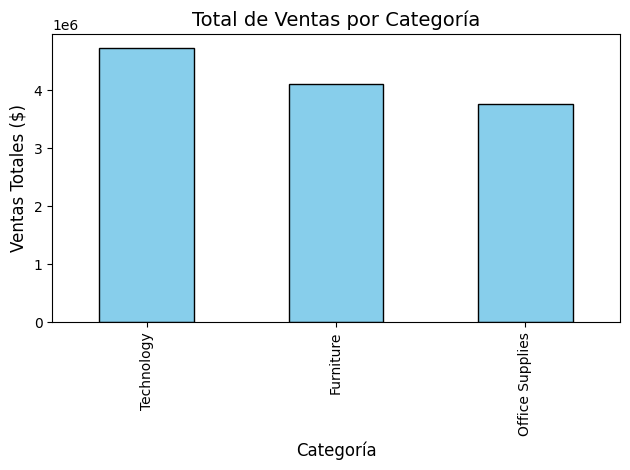

In [0]:

# =====================================================
# 7. NumPy Basics
# =====================================================================
# OPERACIONES MATEMÁTICAS RÁPIDAS CON NUMPY
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt

# 1. Crear Arrays de NumPy: Convertimos las columnas a un formato matemático súper rápido.
sales_array = np.array(pdf_clean["Sales"])
profit_array = np.array(pdf_clean["Profit"])

# 2. Operaciones básicas: Usamos print() y f-strings para ver todos los resultados del diagnóstico.
print("\n--- RESUMEN DE VENTAS ---")
print(f"Promedio de ventas: ${sales_array.mean():.2f}")
print(f"Venta máxima registrada: ${sales_array.max():.2f}")
print(f"Venta mínima registrada: ${sales_array.min():.2f}")

# 3. Operaciones Elemento a Elemento (Vectorización):
# Calcula el margen de ganancia (Ganancia / Ventas) en toda la base de datos a la vez.
profit_margin = profit_array / sales_array

print("\n--- MARGEN DE GANANCIA ---")
print(f"Primeros 10 márgenes calculados: \n{profit_margin[:10]}")

# 4. Filtro Booleano: 
# Busca las ventas con un margen mayor al 30% (> 0.3) y suma cuántas fueron en total.
high_margin = profit_margin > 0.3
total_high_margin = high_margin.sum()
print(f"Total de ventas con un margen superior al 30%: {total_high_margin} transacciones")


# =====================================================================
# 8. COMBINANDO PANDAS & NUMPY (FEATURE ENGINEERING)
# =====================================================================

# Agregamos nuestra nueva variable calculada (Profit_Margin) como una columna nueva a la tabla.
pdf_clean["Profit_Margin"] = profit_margin

print("\n--- VISTA PREVIA DE LA TABLA ACTUALIZADA ---")
# Usamos print() para ver las primeras 5 filas de las columnas seleccionadas
print(pdf_clean[["Sales", "Profit", "Profit_Margin"]].head())


# =====================================================================
# 9. VISUALIZACIÓN DE DATOS CON MATPLOTLIB
# =====================================================================

print("\n--- GENERANDO GRÁFICO ---")
# Creamos un gráfico de barras usando los datos agrupados previamente (sales_by_category)
sales_by_category.plot(kind="bar", color='skyblue', edgecolor='black')

# Configuraciones de las etiquetas del gráfico
plt.title("Total de Ventas por Categoría", fontsize=14)
plt.xlabel("Categoría", fontsize=12)
plt.ylabel("Ventas Totales ($)", fontsize=12)

# Ajusta los márgenes para que los nombres de las categorías no se corten
plt.tight_layout()

# Muestra el gráfico en la pantalla de Databricks
plt.show()



In [0]:

# =====================================================
# 10. Mini Student Exercise
# =====================================================
# =====================================================================
# FILTRADO Y AGRUPACIÓN AVANZADA (METHOD CHAINING)
# =====================================================================

# 1. Ejecutamos múltiples operaciones en un solo paso
exercise = (
    # Paso A: Filtrar solo las compras que tienen más de 5 artículos en cantidad
    pdf_clean[pdf_clean["Quantity"] > 5]
    
    # Paso B: Agrupar por 'Sub-Categoría' y tomar la columna de 'Ventas'
    .groupby("Sub-Category")["Sales"]
    
    # Paso C: Calcular el ticket promedio (media) de esas ventas
    .mean()
    
    # Paso D: Ordenar los promedios de mayor a menor
    .sort_values(ascending=False)
)

# 2. Imprimir los resultados con formato claro
print("\n--- TOP 5 SUB-CATEGORÍAS POR PROMEDIO DE VENTAS ---")
print("(Filtrado exclusivo para compras mayores a 5 artículos)")
print("-" * 55)
# Mostramos los primeros 5 resultados
print(exercise.head())



--- TOP 5 SUB-CATEGORÍAS POR PROMEDIO DE VENTAS ---
(Filtrado exclusivo para compras mayores a 5 artículos)
-------------------------------------------------------
Sub-Category
Tables        1676.772152
Copiers       1421.577713
Appliances    1329.304659
Bookcases     1298.549751
Machines      1150.630252
Name: Sales, dtype: float64


In [0]:

# =====================================================
# 11. Key Takeaways
# =====================================================
# - Pandas is ideal for small to medium datasets
# - NumPy enables fast numerical operations
# - Databricks supports hybrid Spark + Pandas workflows
# - Typical workflow:
#   Load -> Clean -> Analyze -> Visualize

# End of Notebook


In [0]:
# =====================================================================
# INSPECCIÓN VISUAL DE LOS DATOS (VISTAZOS RÁPIDOS)
# =====================================================================

# 1. Mostrar las primeras 5 filas de la base de datos
print("\n--- PRIMERAS 5 FILAS (HEAD) ---")
print("Sirve para ver la estructura inicial y cómo entraron los datos:")
print(pdf.head())

# 2. Mostrar las últimas 5 filas de la base de datos
print("\n--- ÚLTIMAS 5 FILAS (TAIL) ---")
print("Sirve para verificar el final del archivo y detectar filas basura o de 'totales':")
print(pdf.tail())

# 3. Extraer 5 filas aleatorias
print("\n--- 5 FILAS AL AZAR (SAMPLE) ---")
print("Sirve para auditar la calidad de los datos sin sesgarnos por el principio o el final:")
print(pdf.sample(5))



--- PRIMERAS 5 FILAS (HEAD) ---
Sirve para ver la estructura inicial y cómo entraron los datos:
                   Order ID  Order Date  ... order year order month
0  CA-2014-AB10015140-41954  2014-11-11  ...       2014          11
1    IN-2014-JR162107-41675  2014-02-05  ...       2014           2
2    IN-2014-CR127307-41929  2014-10-17  ...       2014          10
3   ES-2014-KM1637548-41667  2014-01-28  ...       2014           1
4   SG-2014-RH9495111-41948  2014-11-05  ...       2014          11

[5 rows x 25 columns]

--- ÚLTIMAS 5 FILAS (TAIL) ---
Sirve para verificar el final del archivo y detectar filas basura o de 'totales':
                       Order ID  Order Date  ... order year order month
51285   IN-2015-KE1642066-42174  2015-06-19  ...       2015           6
51286  US-2014-ZD21925140-41765  2014-05-06  ...       2014           5
51287  CA-2012-ZD21925140-41147  2012-08-26  ...       2012           8
51288   MX-2013-RB1979518-41322  2013-02-17  ...       2013           

In [0]:
pdf.shape        # (filas, columnas)
pdf.columns
pdf.dtypes

In [0]:
pdf["Category"].value_counts()

Office Supplies    31289
Technology         10141
Furniture           9860
Name: Category, dtype: int64

In [0]:
pdf.sort_values("Sales", ascending=False).head(10)



,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Delivery Days,order year,order month
47114,CA-2012-SM20320140-40985,2012-03-17,2012-03-22,Standard Class,SM-203201408,Sean Miller,Home Office,Jacksonville,Florida,United States,Southern US,USCA,TEC-MA-3819,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638,6,0.5,-1811,24,Medium,5,2012,3
49003,CA-2014-TC20980140-41915,2014-10-03,2014-10-10,Standard Class,TC-209801402,Tamara Chand,Corporate,Lafayette,Indiana,United States,Central US,USCA,TEC-CO-3691,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499,5,0.0,8399,349,Medium,7,2014,10
44248,CA-2015-RB19360140-42087,2015-03-24,2015-03-26,First Class,RB-193601404,Raymond Buch,Consumer,Seattle,Washington,United States,Western US,USCA,TEC-CO-3691,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999,4,0.0,6719,20,Medium,2,2015,3
49940,CA-2015-TA21385140-42300,2015-10-23,2015-10-25,First Class,TA-213851406,Tom Ashbrook,Home Office,New York City,New York,United States,Eastern US,USCA,TEC-CO-3691,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199,4,0.2,3919,45,High,2,2015,10
25238,CA-2015-HL15040140-42326,2015-11-18,2015-11-23,Standard Class,HL-150401406,Hunter Lopez,Consumer,Newark,Delaware,United States,Eastern US,USCA,TEC-CO-3691,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499,3,0.0,5039,363,Medium,5,2015,11
419,CA-2014-AB10105140-41991,2014-12-18,2014-12-22,Standard Class,AB-101051402,Adrian Barton,Consumer,Detroit,Michigan,United States,Central US,USCA,OFF-BI-4345,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892,13,0.0,4946,498,Medium,4,2014,12
46295,CA-2012-SC20095140-41174,2012-09-22,2012-09-27,Standard Class,SC-200951402,Sanjit Chand,Consumer,Minneapolis,Minnesota,United States,Central US,USCA,OFF-BI-4821,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449,5,0.0,4630,655,Medium,5,2012,9
6422,US-2014-BS11365140-41746,2014-04-17,2014-04-21,Standard Class,BS-113651406,Bill Shonely,Corporate,Lakewood,New Jersey,United States,Eastern US,USCA,TEC-MA-2865,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099,7,0.0,2365,516,Medium,4,2014,4
46386,CA-2014-SE20110140-41672,2014-02-02,2014-02-04,Second Class,SE-201101408,Sanjit Engle,Consumer,Arlington,Virginia,United States,Southern US,USCA,TEC-MA-4768,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749,5,0.0,2799,17,Critical,2,2014,2
11063,CA-2014-CC12370140-41783,2014-05-24,2014-05-28,Standard Class,CC-123701406,Christopher Conant,Consumer,Philadelphia,Pennsylvania,United States,Eastern US,USCA,TEC-CO-3691,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,8399,4,0.4,1119,498,Medium,4,2014,5


In [0]:
pdf[pdf["Sales"] > 500]


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Delivery Days,order year,order month
1,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,Oceania,Asia Pacific,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709,9,0.1,-288,923,Critical,2,2014,2
2,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,Brisbane,Queensland,Australia,Oceania,Asia Pacific,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175,9,0.1,919,915,Medium,1,2014,10
3,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,Berlin,Berlin,Germany,Western Europe,Europe,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892,5,0.1,-96,910,Medium,2,2014,1
4,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Western Africa,Africa,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832,8,0.0,311,903,Critical,1,2014,11
5,IN-2014-JM156557-41818,2014-06-28,2014-07-01,Second Class,JM-156557,Jim Mitchum,Corporate,Sydney,New South Wales,Australia,Oceania,Asia Pacific,TEC-PH-5842,Technology,Phones,"Samsung Smart Phone, with Caller ID",2862,5,0.1,763,897,Critical,3,2014,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51192,CA-2012-ZC21910140-41194,2012-10-12,2012-10-14,First Class,ZC-219101404,Zuschuss Carroll,Consumer,Edmonds,Washington,United States,Western US,USCA,FUR-TA-3425,Furniture,Tables,"Bevis Round Bullnose 29"" High Table Top",1298,5,0.0,311,146,High,2,2012,10
51193,CA-2013-ZC21910140-41530,2013-09-13,2013-09-18,Standard Class,ZC-219101402,Zuschuss Carroll,Consumer,Columbus,Indiana,United States,Central US,USCA,FUR-CH-4670,Furniture,Chairs,Hon Multipurpose Stacking Arm Chairs,1516,7,0.0,394,132,Medium,5,2013,9
51195,CA-2013-ZC21910140-41377,2013-04-13,2013-04-19,Standard Class,ZC-219101404,Zuschuss Carroll,Consumer,Pomona,California,United States,Western US,USCA,FUR-TA-4625,Furniture,Tables,Hon 94000 Series Round Tables,710,3,0.2,-97,67,Medium,6,2013,4
51200,CA-2014-ZC21910140-41707,2014-03-09,2014-03-14,Standard Class,ZC-219101408,Zuschuss Carroll,Consumer,Miami,Florida,United States,Southern US,USCA,TEC-PH-3820,Technology,Phones,Cisco Unified IP Phone 7945G VoIP phone,1363,5,0.2,85,61,Medium,5,2014,3


In [0]:
pdf[(pdf["Sales"] > 500) & (pdf["Profit"] > 0)]

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Delivery Days,order year,order month
2,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,Brisbane,Queensland,Australia,Oceania,Asia Pacific,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175,9,0.1,919,915,Medium,1,2014,10
4,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Western Africa,Africa,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832,8,0.0,311,903,Critical,1,2014,11
5,IN-2014-JM156557-41818,2014-06-28,2014-07-01,Second Class,JM-156557,Jim Mitchum,Corporate,Sydney,New South Wales,Australia,Oceania,Asia Pacific,TEC-PH-5842,Technology,Phones,"Samsung Smart Phone, with Caller ID",2862,5,0.1,763,897,Critical,3,2014,6
6,IN-2012-TS2134092-41219,2012-11-06,2012-11-08,First Class,TS-2134092,Toby Swindell,Consumer,Porirua,Wellington,New Zealand,Oceania,Asia Pacific,FUR-CH-5378,Furniture,Chairs,"Novimex Executive Leather Armchair, Adjustable",1822,4,0.0,564,894,Critical,2,2012,11
7,IN-2013-MB1808592-41378,2013-04-14,2013-04-18,Standard Class,MB-1808592,Mick Brown,Consumer,Hamilton,Waikato,New Zealand,Oceania,Asia Pacific,FUR-TA-3764,Furniture,Tables,"Chromcraft Conference Table, Fully Assembled",5244,6,0.0,996,878,High,4,2013,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51153,CA-2015-YC21895140-42365,2015-12-27,2015-12-27,Same Day,YC-218951402,Yoseph Carroll,Corporate,Fremont,Nebraska,United States,Central US,USCA,OFF-ST-6294,Office Supplies,Storage,Tennsco Single-Tier Lockers,750,2,0.0,37,163,High,0,2015,12
51192,CA-2012-ZC21910140-41194,2012-10-12,2012-10-14,First Class,ZC-219101404,Zuschuss Carroll,Consumer,Edmonds,Washington,United States,Western US,USCA,FUR-TA-3425,Furniture,Tables,"Bevis Round Bullnose 29"" High Table Top",1298,5,0.0,311,146,High,2,2012,10
51193,CA-2013-ZC21910140-41530,2013-09-13,2013-09-18,Standard Class,ZC-219101402,Zuschuss Carroll,Consumer,Columbus,Indiana,United States,Central US,USCA,FUR-CH-4670,Furniture,Chairs,Hon Multipurpose Stacking Arm Chairs,1516,7,0.0,394,132,Medium,5,2013,9
51200,CA-2014-ZC21910140-41707,2014-03-09,2014-03-14,Standard Class,ZC-219101408,Zuschuss Carroll,Consumer,Miami,Florida,United States,Southern US,USCA,TEC-PH-3820,Technology,Phones,Cisco Unified IP Phone 7945G VoIP phone,1363,5,0.2,85,61,Medium,5,2014,3


In [0]:
pdf[(pdf["Region"] == "West") | (pdf["Region"] == "East")]


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Delivery Days,order year,order month


In [0]:
pdf["Profit_Ratio"] = pdf["Profit"] / pdf["Sales"]
pdf["Profit_Ratio"]


0        0.280543
1       -0.077649
2        0.177585
3       -0.033195
4        0.109816
           ...   
51285    0.061538
51286    0.187500
51287    0.250000
51288    0.153846
51289    0.016393
Name: Profit_Ratio, Length: 51290, dtype: float64

In [0]:
# =====================================================================
# ESTADÍSTICA DESCRIPTIVA (DIAGNÓSTICO DE LA VARIABLE "VENTAS")
# =====================================================================

# Calculamos y guardamos las métricas
ventas_promedio = pdf["Sales"].mean()
ventas_mediana = pdf["Sales"].median()
ventas_desviacion = pdf["Sales"].std()
ventas_total = pdf["Sales"].sum()

# Mostramos un reporte estructurado en pantalla
print("\n--- DIAGNÓSTICO ESTADÍSTICO DE VENTAS (SALES) ---")
print("-" * 60)
print(f"1. Total Ingresos Brutos (Sum):      ${ventas_total:,.2f}")
print(f"2. Venta Promedio (Mean):            ${ventas_promedio:,.2f}")
print(f"3. Venta Típica / Mediana (Median):  ${ventas_mediana:,.2f}")
print(f"4. Volatilidad / Dispersión (Std):   ${ventas_desviacion:,.2f}")
print("-" * 60)

# Breve diagnóstico automático como nota
if ventas_promedio > ventas_mediana:
    print("💡 DIAGNÓSTICO: El promedio es mayor que la mediana. Esto indica que hay\n"
          "ventas muy altas (outliers) que están jalando el promedio hacia arriba.")


--- DIAGNÓSTICO ESTADÍSTICO DE VENTAS (SALES) ---
------------------------------------------------------------
1. Total Ingresos Brutos (Sum):      $12,616,022.00
2. Venta Promedio (Mean):            $245.97
3. Venta Típica / Mediana (Median):  $85.00
4. Volatilidad / Dispersión (Std):   $487.56
------------------------------------------------------------
💡 DIAGNÓSTICO: El promedio es mayor que la mediana. Esto indica que hay
ventas muy altas (outliers) que están jalando el promedio hacia arriba.


In [0]:
# =====================================================================
# ANÁLISIS DE CORRELACIÓN (RELACIÓN ENTRE VARIABLES)
# =====================================================================

# 1. Calculamos la matriz de correlación completa entre ambas columnas
matriz_correlacion = pdf[["Sales", "Profit"]].corr()

print("\n--- MATRIZ DE CORRELACIÓN ---")
print("Muestra la tabla cruzada de relaciones:")
print(matriz_correlacion)

# 2. Extraemos el valor exacto de correlación para evaluarlo directamente
# (Calculamos la correlación de una columna específicamente contra la otra)
valor_corr = pdf["Sales"].corr(pdf["Profit"])

print("\n--- DIAGNÓSTICO DE PREDICTIBILIDAD ---")
print(f"El nivel de correlación entre Ventas y Ganancias es: {valor_corr:.4f}")

# Evaluación automática para el diagnóstico
if valor_corr > 0.7:
    print("💡 DIAGNÓSTICO: Fuerte relación positiva. Las ventas son excelentes predictores de las ganancias.")
elif valor_corr > 0.3:
    print("💡 DIAGNÓSTICO: Relación positiva moderada/débil. Las ventas influyen en las ganancias, pero hay otros factores afectando (ej. altos costos o descuentos).")
else:
    print("💡 DIAGNÓSTICO: Relación muy débil o nula. Vender más no garantiza ganar más.")


--- MATRIZ DE CORRELACIÓN ---
Muestra la tabla cruzada de relaciones:
           Sales    Profit
Sales   1.000000  0.485159
Profit  0.485159  1.000000

--- DIAGNÓSTICO DE PREDICTIBILIDAD ---
El nivel de correlación entre Ventas y Ganancias es: 0.4852
💡 DIAGNÓSTICO: Relación positiva moderada/débil. Las ventas influyen en las ganancias, pero hay otros factores afectando (ej. altos costos o descuentos).


In [0]:
pdf.groupby("Category")["Sales"].sum()

Category
Furniture          4105451
Office Supplies    3771481
Technology         4739090
Name: Sales, dtype: int64

In [0]:
# =====================================================================
# AGRUPACIONES COMPLEJAS CON .agg() (MÚLTIPLES MÉTRICAS)
# =====================================================================

# Utilizamos .agg() para aplicar diferentes cálculos a distintas columnas en un solo paso
resumen_categorias = pdf.groupby("Category").agg({
    "Sales": "sum",       # Calcula el Ingreso Total
    "Profit": "mean",     # Calcula la Ganancia Promedio por venta
    "Quantity": "count"   # Cuenta el Número Total de transacciones
})

# Renombramos las columnas para que el reporte sea más profesional y fácil de leer
resumen_categorias.columns = ["Ingreso_Total", "Ganancia_Promedio", "Total_Transacciones"]

# Imprimimos el reporte final con un formato claro
print("\n--- REPORTE MULTIDIMENSIONAL POR CATEGORÍA ---")
print("Muestra Volumen de Ventas, Rentabilidad Promedio y Tráfico a la vez:")
print("-" * 75)
print(resumen_categorias)


--- REPORTE MULTIDIMENSIONAL POR CATEGORÍA ---
Muestra Volumen de Ventas, Rentabilidad Promedio y Tráfico a la vez:
---------------------------------------------------------------------------
                 Ingreso_Total  Ganancia_Promedio  Total_Transacciones
Category                                                              
Furniture              4105451          28.733063                 9860
Office Supplies        3771481          16.308575                31289
Technology             4739090          65.185780                10141


In [0]:
# =====================================================================
# BÚSQUEDA DE VALORES MÁS ALTOS (TOP N OUTLIERS)
# =====================================================================

# .nlargest() extrae las 'n' filas con los valores más altos en la columna indicada.
# Es la forma más eficiente de encontrar las transacciones más grandes sin ordenar toda la tabla.

top_5_ventas = pdf.nlargest(5, "Sales")

print("\n--- TOP 5: LAS TRANSACCIONES MÁS GRANDES DEL NEGOCIO ---")
print("Muestra los detalles clave de las 5 ventas que generaron más ingresos:")
print("-" * 80)

# Para que el resultado en Databricks sea fácil de leer, seleccionamos solo columnas de interés:
columnas_clave = ["Customer Name", "Category", "Sub-Category", "Sales", "Profit"]

print(top_5_ventas[columnas_clave])


--- TOP 5: LAS TRANSACCIONES MÁS GRANDES DEL NEGOCIO ---
Muestra los detalles clave de las 5 ventas que generaron más ingresos:
--------------------------------------------------------------------------------
      Customer Name    Category Sub-Category  Sales  Profit
47114   Sean Miller  Technology     Machines  22638   -1811
49003  Tamara Chand  Technology      Copiers  17499    8399
44248  Raymond Buch  Technology      Copiers  13999    6719
49940  Tom Ashbrook  Technology      Copiers  11199    3919
25238  Hunter Lopez  Technology      Copiers  10499    5039


In [0]:
# =====================================================================
# BÚSQUEDA DE PEORES RESULTADOS (TOP N PÉRDIDAS)
# =====================================================================

# .nsmallest() extrae las 'n' filas con los valores más bajos en la columna indicada.
# Ideal para encontrar los valores más negativos (pérdidas extremas).

peores_5_ganancias = pdf.nsmallest(5, "Profit")

print("\n--- TOP 5: LAS MAYORES PÉRDIDAS DEL NEGOCIO ---")
print("Muestra los detalles de las 5 transacciones que más dinero le costaron a la empresa:")
print("-" * 85)

# Seleccionamos columnas de interés para diagnosticar el porqué de la pérdida
columnas_diagnostico = ["Customer Name", "Category", "Sales", "Discount", "Profit"]

print(peores_5_ganancias[columnas_diagnostico])

# Pequeña nota de diagnóstico
print("-" * 85)
print("💡 DIAGNÓSTICO: Revisa la columna 'Discount' (Descuento). Las peores pérdidas")
print("suelen estar correlacionadas con descuentos excesivos o altos costos de envío.")


--- TOP 5: LAS MAYORES PÉRDIDAS DEL NEGOCIO ---
Muestra los detalles de las 5 transacciones que más dinero le costaron a la empresa:
-------------------------------------------------------------------------------------
        Customer Name         Category  Sales  Discount  Profit
11755   Cindy Stewart       Technology   4499       0.7   -6599
6591    Denise Monton       Technology   3085       0.6   -4088
23110  Grant Thornton       Technology   7999       0.5   -3839
36327     Luke Foster  Office Supplies   2177       0.8   -3701
47527  Sharelle Roach       Technology   2549       0.7   -3399
-------------------------------------------------------------------------------------
💡 DIAGNÓSTICO: Revisa la columna 'Discount' (Descuento). Las peores pérdidas
suelen estar correlacionadas con descuentos excesivos o altos costos de envío.


In [0]:
pdf.isna().sum()

Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Region            0
Market            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
Delivery Days     0
order year        0
order month       0
Profit_Ratio      3
dtype: int64

In [0]:
pdf.dropna()



,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Delivery Days,order year,order month,Profit_Ratio
0,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,Oklahoma City,Oklahoma,United States,Central US,USCA,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221,2,0.0,62,40,High,2,2014,11,0.280543
1,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,Oceania,Asia Pacific,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709,9,0.1,-288,923,Critical,2,2014,2,-0.077649
2,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,Brisbane,Queensland,Australia,Oceania,Asia Pacific,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175,9,0.1,919,915,Medium,1,2014,10,0.177585
3,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,Berlin,Berlin,Germany,Western Europe,Europe,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892,5,0.1,-96,910,Medium,2,2014,1,-0.033195
4,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Western Africa,Africa,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832,8,0.0,311,903,Critical,1,2014,11,0.109816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,IN-2015-KE1642066-42174,2015-06-19,2015-06-19,Same Day,KE-1642066,Katrina Edelman,Corporate,Kure,Hiroshima,Japan,Eastern Asia,Asia Pacific,OFF-FA-3072,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65,5,0.0,4,1,Medium,0,2015,6,0.061538
51286,US-2014-ZD21925140-41765,2014-05-06,2014-05-10,Standard Class,ZD-219251408,Zuschuss Donatelli,Consumer,Chattanooga,Tennessee,United States,Southern US,USCA,FUR-FU-4070,Furniture,Furnishings,"Eldon Image Series Desk Accessories, Burgundy",16,5,0.2,3,1,High,4,2014,5,0.187500
51287,CA-2012-ZD21925140-41147,2012-08-26,2012-08-31,Second Class,ZD-219251404,Zuschuss Donatelli,Consumer,San Francisco,California,United States,Western US,USCA,OFF-AR-5321,Office Supplies,Art,Newell 341,8,2,0.0,2,1,High,5,2012,8,0.250000
51288,MX-2013-RB1979518-41322,2013-02-17,2013-02-21,Standard Class,RB-1979518,Ross Baird,Home Office,Valinhos,São Paulo,Brazil,South America,LATAM,OFF-BI-2919,Office Supplies,Binders,"Acco Index Tab, Economy",13,2,0.0,2,1,Medium,4,2013,2,0.153846


In [0]:
# =====================================================================
# MANEJO DE DATOS FALTANTES (IMPUTACIÓN CON FILLNA)
# =====================================================================

# 1. Diagnóstico previo: Contamos cuántos nulos hay ANTES de rellenar
nulos_antes = pdf["Profit"].isna().sum()

print("\n--- IMPUTACIÓN DE NULOS EN GANANCIAS (PROFIT) ---")
print(f"Cantidad de valores nulos antes de limpiar: {nulos_antes}")

# 2. Aplicamos fillna(0). 
# NOTA: Usamos el signo '=' para sobrescribir la columna original y guardar los cambios en la base de datos.
pdf["Profit"] = pdf["Profit"].fillna(0)

# 3. Diagnóstico posterior: Verificamos que el cambio fue exitoso
nulos_despues = pdf["Profit"].isna().sum()

print(f"Cantidad de valores nulos después de limpiar: {nulos_despues}")

print("-" * 65)
print("💡 NOTA DE NEGOCIO: Rellenar con 0 asume que el margen fue 'tablas' \n(ni ganancia ni pérdida) cuando el dato no fue registrado.")


--- IMPUTACIÓN DE NULOS EN GANANCIAS (PROFIT) ---
Cantidad de valores nulos antes de limpiar: 0
Cantidad de valores nulos después de limpiar: 0
-----------------------------------------------------------------
💡 NOTA DE NEGOCIO: Rellenar con 0 asume que el margen fue 'tablas' 
(ni ganancia ni pérdida) cuando el dato no fue registrado.


In [0]:
import numpy as np
arr = np.array([10, 20, 30, 40])


arr.mean()
arr.max()
arr.min()


10


--- DISTRIBUCIÓN DE LA VARIABLE VENTAS (SALES) ---
El histograma agrupa las ventas en 20 rangos (bins) para ver dónde se concentra el volumen.
💡 DIAGNÓSTICO: Busca si los datos tienen forma de campana (normal) o si están 
sesgados hacia la izquierda (muchas ventas de bajo valor).


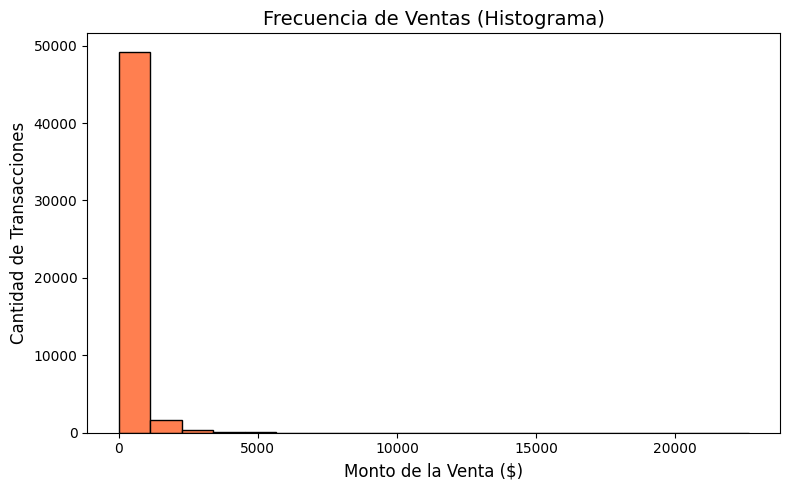

In [0]:
# =====================================================================
# DIAGNÓSTICO DE DISTRIBUCIÓN (HISTOGRAMA)
# =====================================================================
import matplotlib.pyplot as plt

print("\n--- DISTRIBUCIÓN DE LA VARIABLE VENTAS (SALES) ---")
print("El histograma agrupa las ventas en 20 rangos (bins) para ver dónde se concentra el volumen.")
print("💡 DIAGNÓSTICO: Busca si los datos tienen forma de campana (normal) o si están ")
print("sesgados hacia la izquierda (muchas ventas de bajo valor).")

# Creamos el gráfico con un color y bordes para que sea fácil de leer
pdf["Sales"].plot(kind="hist", bins=20, color="coral", edgecolor="black", figsize=(8, 5))

# Configuramos títulos y etiquetas
plt.title("Frecuencia de Ventas (Histograma)", fontsize=14)
plt.xlabel("Monto de la Venta ($)", fontsize=12)
plt.ylabel("Cantidad de Transacciones", fontsize=12)

# Ajustamos márgenes
plt.tight_layout()

# Mostramos el gráfico
plt.show()


--- GENERANDO DIAGRAMA DE CAJA (BOXPLOT) ---
Este gráfico compara la distribución de las Ventas separadas por Categoría.
💡 DIAGNÓSTICO VISUAL:
 - La caja contiene el 50% de las transacciones típicas.
 - La línea dentro de la caja es la Mediana de ventas.
 - Los círculos/puntos sueltos son los Valores Atípicos (Outliers).


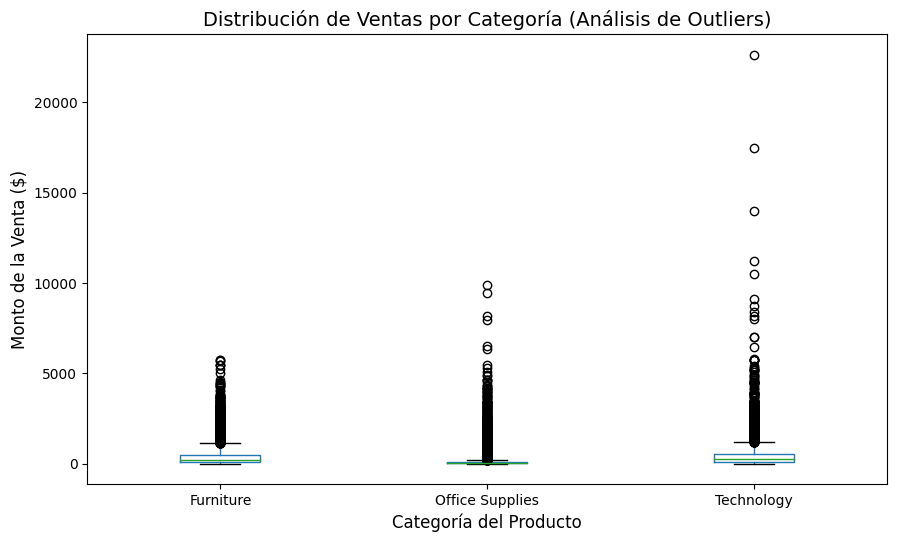

In [0]:
# =====================================================================
# DIAGNÓSTICO DE VALORES ATÍPICOS Y DISPERSIÓN (BOXPLOT)
# =====================================================================
import matplotlib.pyplot as plt

print("\n--- GENERANDO DIAGRAMA DE CAJA (BOXPLOT) ---")
print("Este gráfico compara la distribución de las Ventas separadas por Categoría.")
print("💡 DIAGNÓSTICO VISUAL:")
print(" - La caja contiene el 50% de las transacciones típicas.")
print(" - La línea dentro de la caja es la Mediana de ventas.")
print(" - Los círculos/puntos sueltos son los Valores Atípicos (Outliers).")

# Generamos el boxplot: analizamos 'Sales' separándolo por 'Category'
# figsize=(10, 6) ajusta el tamaño para que no se vea aplastado en Databricks
pdf.boxplot(column="Sales", by="Category", figsize=(10, 6), grid=False)

# Mejoramos la estética de los títulos y etiquetas
plt.title("Distribución de Ventas por Categoría (Análisis de Outliers)", fontsize=14)
plt.suptitle("") # Elimina el subtítulo automático de Pandas que ensucia el gráfico
plt.xlabel("Categoría del Producto", fontsize=12)
plt.ylabel("Monto de la Venta ($)", fontsize=12)

# Mostramos el gráfico
plt.show()


--- GRÁFICO DE DISPERSIÓN: VENTAS VS GANANCIAS ---
Este gráfico evalúa visualmente la correlación entre dos variables numéricas.
💡 DIAGNÓSTICO VISUAL:
 - Si los puntos suben en diagonal, existe una relación positiva.
 - ¡Puntos abajo a la derecha representan ventas gigantes con pérdidas masivas!
---------------------------------------------------------------------------


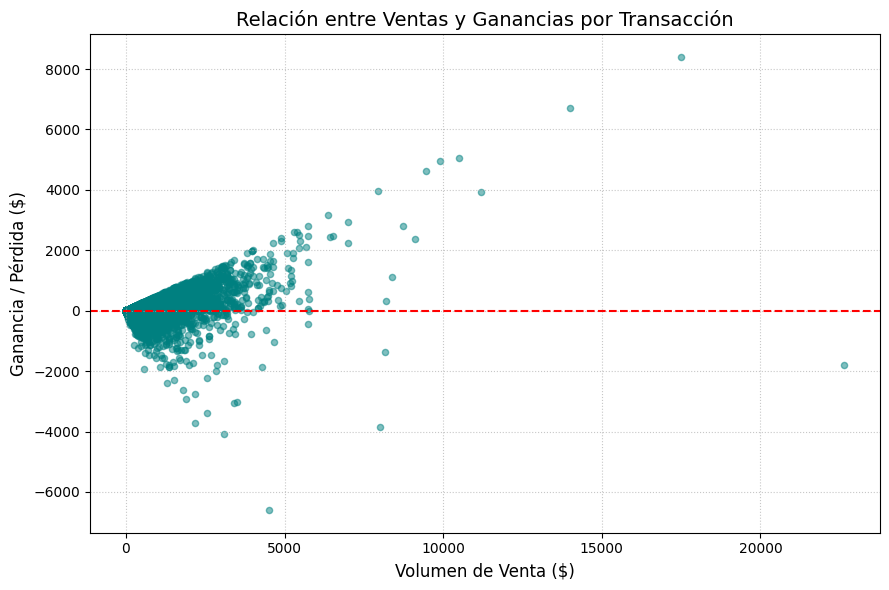

In [0]:
# =====================================================================
# DIAGNÓSTICO DE RELACIONES (GRÁFICO DE DISPERSIÓN / SCATTER PLOT)
# =====================================================================
import matplotlib.pyplot as plt

print("\n--- GRÁFICO DE DISPERSIÓN: VENTAS VS GANANCIAS ---")
print("Este gráfico evalúa visualmente la correlación entre dos variables numéricas.")
print("💡 DIAGNÓSTICO VISUAL:")
print(" - Si los puntos suben en diagonal, existe una relación positiva.")
print(" - ¡Puntos abajo a la derecha representan ventas gigantes con pérdidas masivas!")
print("-" * 75)

# Creamos el gráfico de dispersión (scatter)
# alpha=0.5 hace que los puntos sean semitransparentes para distinguir aglomeraciones
pdf.plot(kind="scatter", x="Sales", y="Profit", alpha=0.5, color="teal", figsize=(9, 6))

# Configuramos títulos y etiquetas para que el reporte luzca profesional
plt.title("Relación entre Ventas y Ganancias por Transacción", fontsize=14)
plt.xlabel("Volumen de Venta ($)", fontsize=12)
plt.ylabel("Ganancia / Pérdida ($)", fontsize=12)

# Agregamos una línea horizontal en el Cero para distinguir claramente ganancias de pérdidas
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)

# Mostramos una cuadrícula suave para guiar la vista
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Desplegamos el gráfico en pantalla
plt.show()

In [0]:
(
    pdf[pdf["Sales"] > 500]
    .groupby("Region")["Profit"]
    .mean()
    .sort_values(ascending=False)
)

Region
Central Africa       320.485294
Canada               291.588235
Southern Africa      272.632653
Eastern Europe       264.243421
North Africa         261.756757
Eastern Africa       237.820896
Eastern Asia         236.391304
Southern Asia        235.044492
Northern Europe      197.410112
Eastern US           190.033033
Central Asia         187.714286
Western US           166.788770
Southern Europe      149.906542
Central America      146.838996
Central US           143.355469
Oceania              142.399329
Caribbean            134.227545
Western Europe       129.927919
Southern US          122.227273
South America         96.807571
Western Africa        59.376623
Southeastern Asia     55.812877
Western Asia         -16.978102
Name: Profit, dtype: float64

Ejercio 1

Filtra las órdenes con Sales > 300

Agrupa por Category

Calcula el total de Sales

Ordena de mayor a menor

Muestra las 3 categorías con más ventas

Crea una columna llamada Profit_Margin = Profit / Sales

Filtra solo las órdenes con Profit_Margin > 0.25

Muestra las columnas: Category, Sales, Profit, Profit_Margin

Ordena por Profit_Margin de mayor a menor


In [0]:
# =====================================================================
# EJERCICIO 1
# =====================================================================

print("\n" + "="*60)
print(" PARTE 1: TOP 3 CATEGORÍAS (ÓRDENES > $300)")
print("="*60)

# Paso 1 al 5: Filtrar, agrupar, sumar, ordenar y mostrar el Top 3.
# Todo se hace en un solo bloque usando "Method Chaining"
top_3_categorias = (
    pdf_clean[pdf_clean["Sales"] > 300]    # 1. Filtra las órdenes con Sales > 300
    .groupby("Category")["Sales"]          # 2. Agrupa por Category (aislando Sales)
    .sum()                                 # 3. Calcula el total de Sales
    .sort_values(ascending=False)          # 4. Ordena de mayor a menor
    .head(3)                               # 5. Muestra las 3 categorías con más ventas
)

# Imprimimos el resultado de la primera parte
print("Las 3 categorías que generan más ingresos en compras grandes son:\n")
print(top_3_categorias)


print("\n\n" + "="*60)
print(" PARTE 2: ÓRDENES CON ALTO MARGEN DE GANANCIA (> 25%)")
print("="*60)

# 6. Crea una columna llamada Profit_Margin = Profit / Sales
pdf_clean["Profit_Margin"] = pdf_clean["Profit"] / pdf_clean["Sales"]

# 7 al 9: Filtrar, seleccionar columnas y ordenar
ordenes_alto_margen = (
    pdf_clean[pdf_clean["Profit_Margin"] > 0.25]              # 7. Filtra órdenes con margen > 25% (0.25)
    [["Category", "Sales", "Profit", "Profit_Margin"]]        # 8. Muestra solo estas 4 columnas específicas
    .sort_values(by="Profit_Margin", ascending=False)         # 9. Ordena por Profit_Margin de mayor a menor
)

# Imprimimos el resultado de la segunda parte
# Calculamos cuántas órdenes cumplieron la condición para darle más contexto al reporte
total_ordenes_rentables = len(ordenes_alto_margen)

print(f"Se encontraron un total de {total_ordenes_rentables} órdenes con un margen superior al 25%.\n")
print("Vistazo a las órdenes más rentables (Top 10):\n")
print(ordenes_alto_margen.head(10)) # Usamos head(10) para no saturar la pantalla con miles de filas


 PARTE 1: TOP 3 CATEGORÍAS (ÓRDENES > $300)
Las 3 categorías que generan más ingresos en compras grandes son:

Category
Technology         3968328.0
Furniture          3384371.0
Office Supplies    1968279.0
Name: Sales, dtype: float64


 PARTE 2: ÓRDENES CON ALTO MARGEN DE GANANCIA (> 25%)
Se encontraron un total de 18786 órdenes con un margen superior al 25%.

Vistazo a las órdenes más rentables (Top 10):

              Category  Sales  Profit  Profit_Margin
15559  Office Supplies  192.0    96.0            0.5
2480   Office Supplies   18.0     9.0            0.5
44387  Office Supplies   48.0    24.0            0.5
35208  Office Supplies   50.0    25.0            0.5
4266   Office Supplies  568.0   284.0            0.5
1336         Furniture  782.0   391.0            0.5
8304   Office Supplies   12.0     6.0            0.5
26064  Office Supplies   54.0    27.0            0.5
45859  Office Supplies   48.0    24.0            0.5
37538  Office Supplies   14.0     7.0            0.5


Ejercicio 2

Cree un análisis básico inicial

In [0]:
# =====================================================================
# EJERCICIO 2: ANÁLISIS BÁSICO INICIAL (EDA)
# =====================================================================

print("\n" + "="*70)
print(" 1. ESTRUCTURA Y TAMAÑO DEL DATASET")
print("="*70)
# Conocer el volumen de datos con el que vamos a trabajar
filas, columnas = pdf.shape
print(f"El dataset contiene {filas} transacciones (filas) y {columnas} variables (columnas).")


print("\n" + "="*70)
print(" 2. DIAGNÓSTICO DE CALIDAD (DATOS FALTANTES)")
print("="*70)
# Identificar si hay huecos en la información que debamos limpiar después
datos_nulos = pdf.isna().sum()
nulos_importantes = datos_nulos[datos_nulos > 0] # Filtramos solo las columnas que tengan errores

if nulos_importantes.empty:
    print("✅ ¡Excelente calidad! No se detectaron valores nulos en ninguna columna.")
else:
    print("⚠️ Se detectaron valores nulos en las siguientes columnas:")
    print(nulos_importantes)


print("\n" + "="*70)
print(" 3. RESUMEN ESTADÍSTICO (SALUD FINANCIERA)")
print("="*70)
# Un vistazo rápido a las métricas de dinero y volumen usando .describe()
# Seleccionamos solo columnas clave y redondeamos a 2 decimales para leerlo fácil
resumen_financiero = pdf[["Sales", "Profit", "Quantity", "Discount"]].describe().round(2)
print("Estadísticas clave de Ventas, Ganancias, Cantidades y Descuentos:")
print(resumen_financiero)


print("\n" + "="*70)
print(" 4. RADIOGRAFÍA DEL NEGOCIO (RENDIMIENTO POR CATEGORÍA)")
print("="*70)
# Agrupamos para ver cómo le va a la empresa a nivel macro
radiografia_negocio = pdf.groupby("Category").agg({
    "Sales": "sum",       # Ingresos totales
    "Profit": "sum",      # Ganancia neta
    "Quantity": "count"   # Tráfico (número de ventas)
}).round(2).sort_values(by="Sales", ascending=False)

# Renombramos para el reporte
radiografia_negocio.columns = ["Ingresos_Totales", "Ganancia_Neta", "Transacciones"]
print(radiografia_negocio)

# Calculamos y agregamos el margen global al reporte final
margen_global = (pdf["Profit"].sum() / pdf["Sales"].sum()) * 100
print("-" * 70)
print(f"💡 DIAGNÓSTICO FINAL: El margen de ganancia global de la tienda es del {margen_global:.2f}%")


 1. ESTRUCTURA Y TAMAÑO DEL DATASET
El dataset contiene 51290 transacciones (filas) y 26 variables (columnas).

 2. DIAGNÓSTICO DE CALIDAD (DATOS FALTANTES)
⚠️ Se detectaron valores nulos en las siguientes columnas:
Profit_Ratio    3
dtype: int64

 3. RESUMEN ESTADÍSTICO (SALUD FINANCIERA)
Estadísticas clave de Ventas, Ganancias, Cantidades y Descuentos:
          Sales    Profit  Quantity  Discount
count  51290.00  51290.00  51290.00  51290.00
mean     245.97     28.36      3.48      0.14
std      487.56    174.19      2.28      0.21
min        0.00  -6599.00      1.00      0.00
25%       30.00      0.00      2.00      0.00
50%       85.00      9.00      3.00      0.00
75%      251.00     36.00      5.00      0.20
max    22638.00   8399.00     14.00      0.85

 4. RADIOGRAFÍA DEL NEGOCIO (RENDIMIENTO POR CATEGORÍA)
                 Ingresos_Totales  Ganancia_Neta  Transacciones
Category                                                       
Technology                4739090         6